In [6]:
#### importing packages and libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [7]:
###reading dataset
df=pd.read_csv('sales_data_with_discounts.csv')

In [8]:
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [9]:
#### detailed info about dataset and type of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB


In [10]:
### printing numerical columns from dataset
print(df.select_dtypes(include=['int','float']).columns)

Index(['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
       'Discount Amount', 'Net Sales Value'],
      dtype='object')


In [11]:
#### finding mean ,mode,median, standard deviation of numerical columns 
num_col=df.select_dtypes(include=['int','float'])
### finding categorical categorical columns 
cat_col=df.select_dtypes(include='object')

In [12]:
### mean 
mean=num_col.mean()
mean

Volume                   5.066667
Avg Price            10453.433333
Total Sales Value    33812.835556
Discount Rate (%)       15.155242
Discount Amount       3346.499424
Net Sales Value      30466.336131
dtype: float64

In [13]:
### mode 
mode=num_col.mode().iloc[0]
mode
### mode for categorical columns 
mode_cat_col=cat_col.mode().iloc[0] 
mode_cat_col

Date       01-04-2021
Day          Thursday
SKU               F01
City                C
BU               FMCG
Brand           Jeera
Model    Babaji Cream
Name: 0, dtype: object

In [14]:
### median of numerical columns
median=num_col.median() 
median

Volume                  4.000000
Avg Price            1450.000000
Total Sales Value    5700.000000
Discount Rate (%)      16.577766
Discount Amount       988.933733
Net Sales Value      4677.788059
dtype: float64

In [15]:
### standard deviation 
std_dev=num_col.std() 
std_dev

Volume                   4.231602
Avg Price            18079.904840
Total Sales Value    50535.074173
Discount Rate (%)        4.220602
Discount Amount       4509.902963
Net Sales Value      46358.656624
dtype: float64

In [16]:
#### checking missing values in dataset
df.isnull().sum()

Date                 0
Day                  0
SKU                  0
City                 0
Volume               0
BU                   0
Brand                0
Model                0
Avg Price            0
Total Sales Value    0
Discount Rate (%)    0
Discount Amount      0
Net Sales Value      0
dtype: int64

In [17]:
#### checking duplicates 
df.duplicated().sum()

np.int64(0)

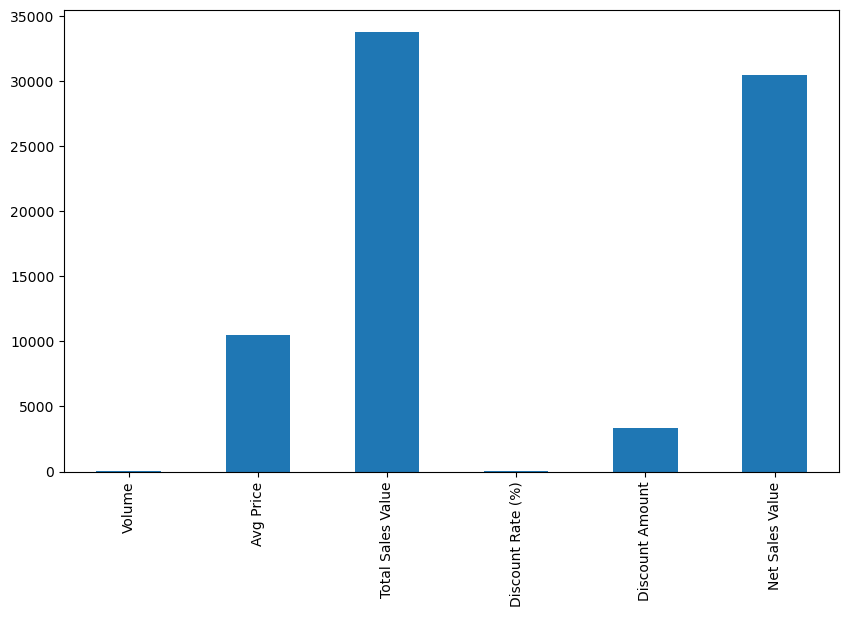

In [20]:
#### bar plot for numerical columns
plt.figure(figsize=(10,6))
bars=mean.plot(kind='bar')

Text(0.5, 1.0, 'Volume')

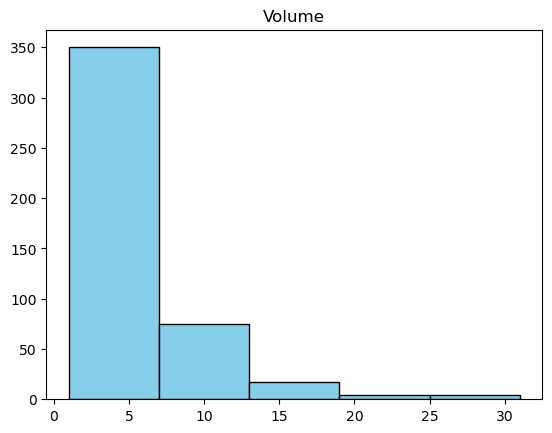

In [62]:

plt.hist(df['Volume'], bins=5, color='skyblue', edgecolor='black')
plt.title('Volume')

Text(0.5, 1.0, 'Avg Price')

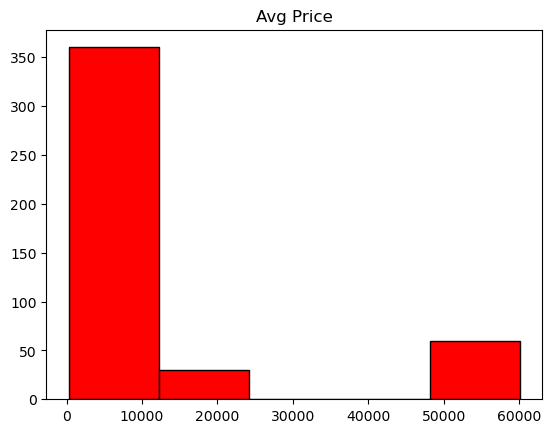

In [63]:
plt.hist(df['Avg Price'], bins=5, color='red', edgecolor='black')
plt.title('Avg Price')

Text(0.5, 1.0, 'Total Sales Value')

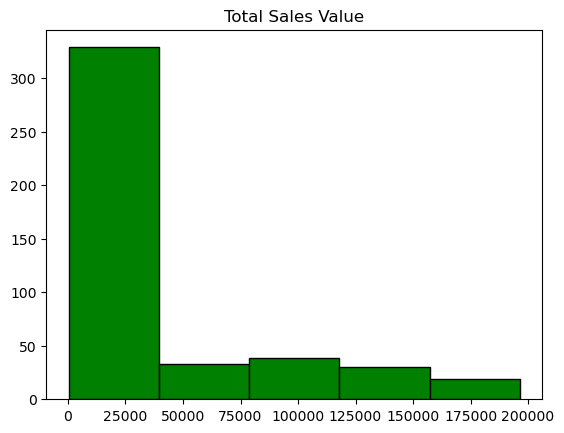

In [64]:
plt.hist(df['Total Sales Value'], bins=5, color='green', edgecolor='black')

plt.title('Total Sales Value')

Text(0.5, 1.0, 'Discount Rate %')

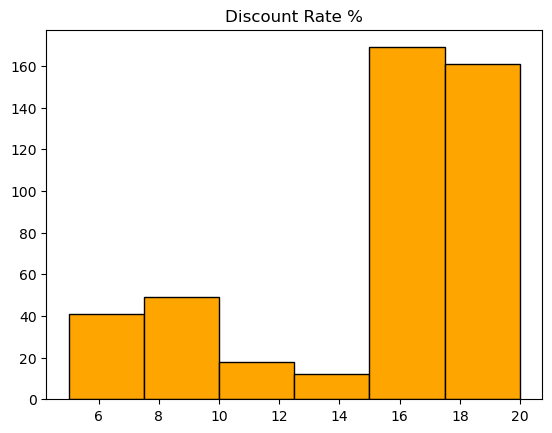

In [65]:
plt.hist(df['Discount Rate (%)'], bins=6, color='orange', edgecolor='black')
plt.title('Discount Rate %')

Text(0.5, 1.0, 'Discount Amount')

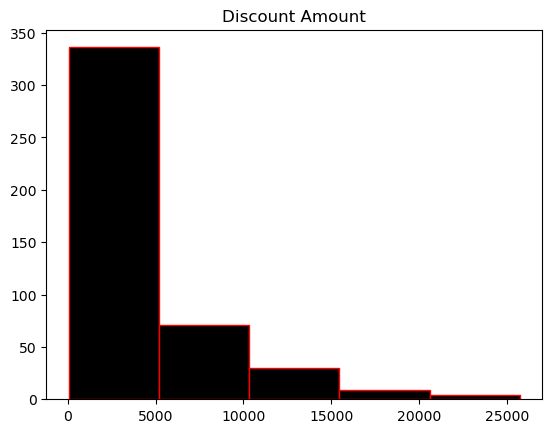

In [66]:
plt.hist(df['Discount Amount'], bins=5, color='k', edgecolor='red')
plt.title('Discount Amount')

Text(0.5, 1.0, 'Net Sales Value')

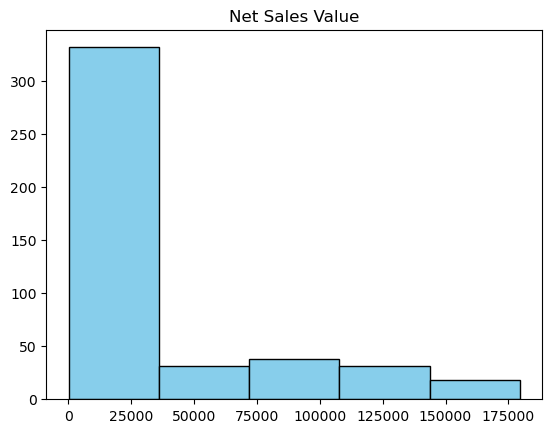

In [67]:
plt.hist(df['Net Sales Value'], bins=5, color='skyblue', edgecolor='black')
plt.title('Net Sales Value')


<Axes: >

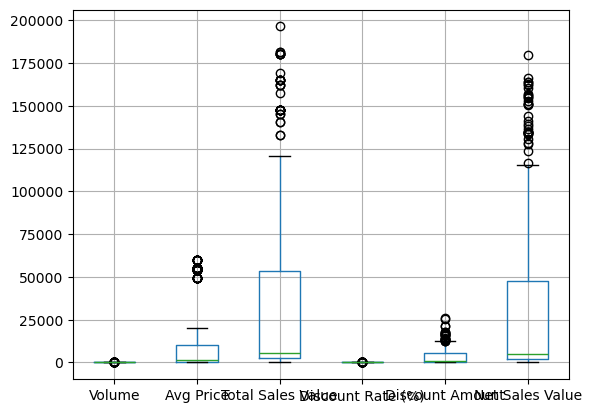

In [68]:
##### checking outliers through boxplot
df.boxplot()

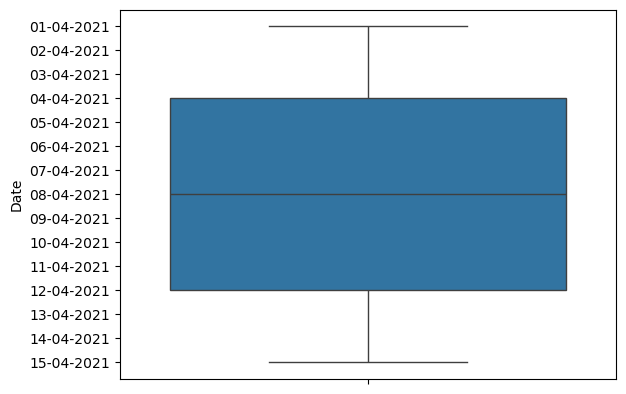

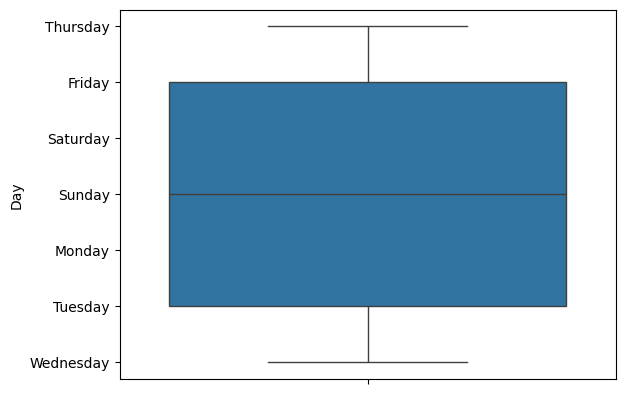

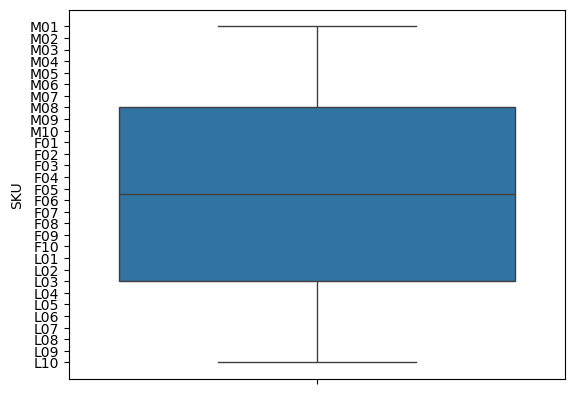

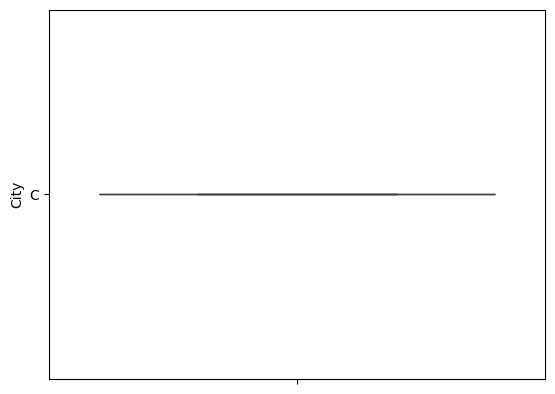

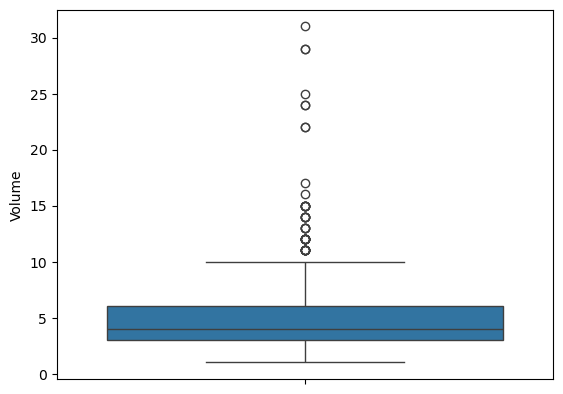

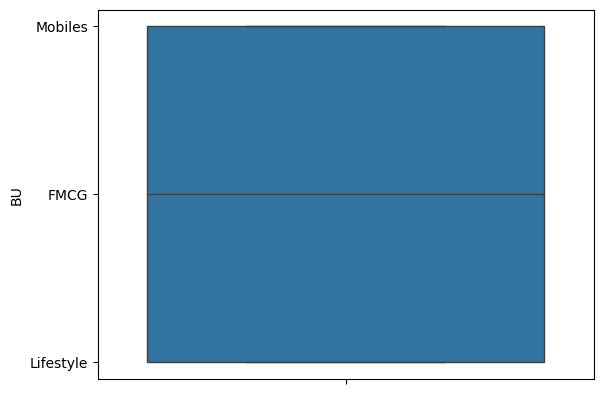

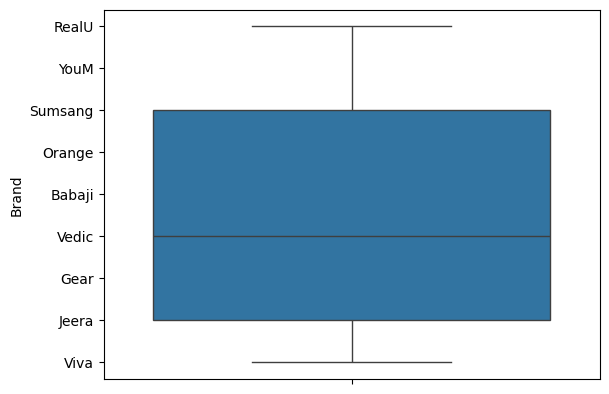

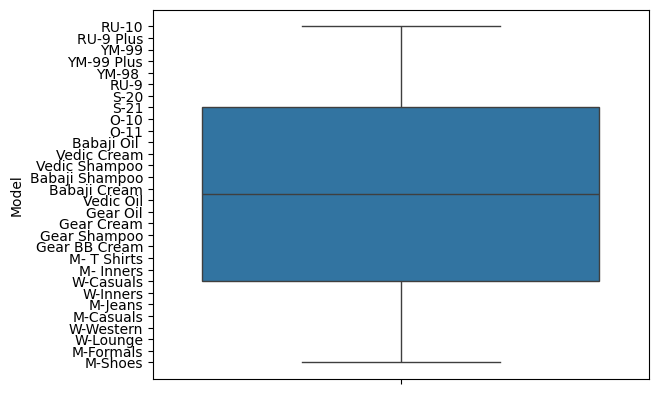

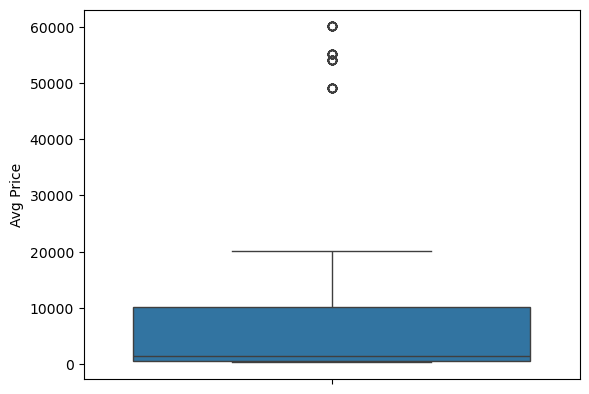

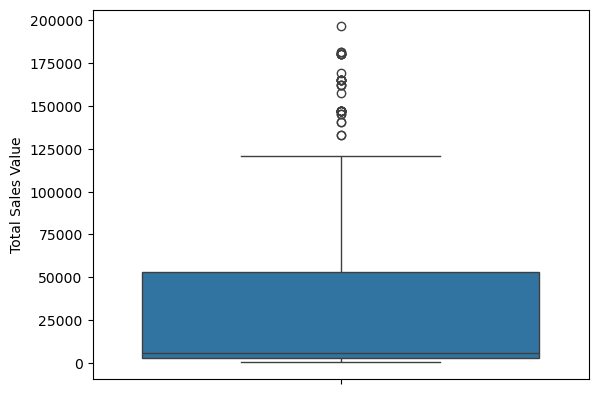

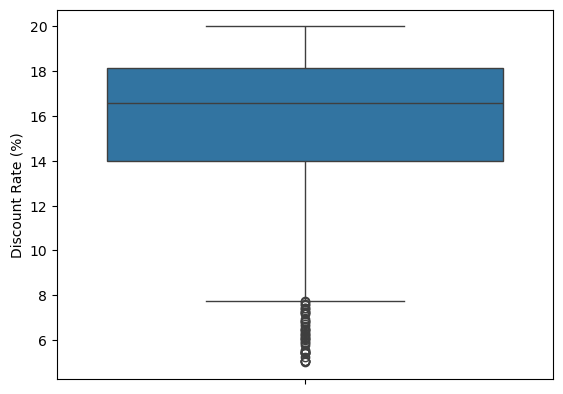

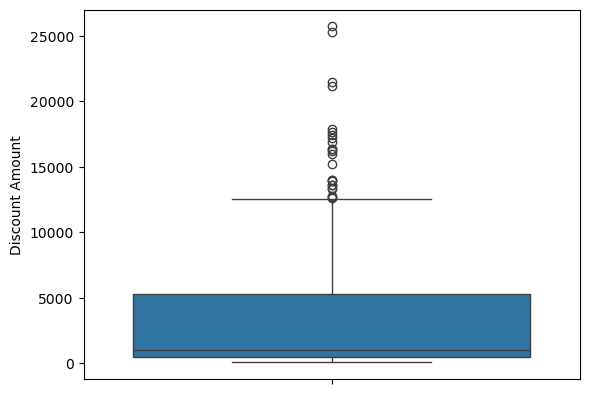

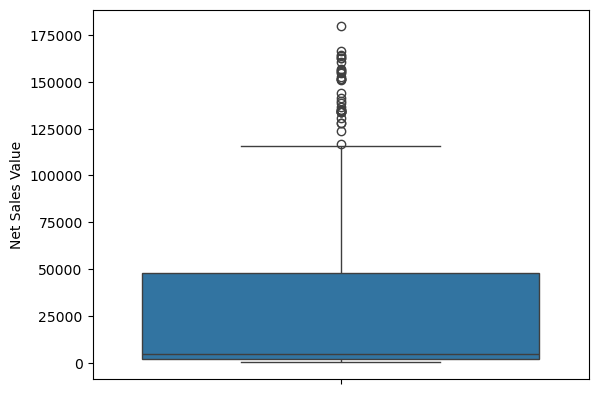

In [69]:
for col in df.columns:
    sns.boxplot(data=df,y=col)
    plt.show()

In [70]:
#### removing outlier from dataset 
def outlier_capping(df,column):
    Q1=df[column].quantile(0.25) 
    Q3=df[column].quantile(0.75) 
    IQR=Q3-Q1 
    lower_extreme=Q1-1.5*IQR 
    upper_extreme=Q3+1.5*IQR 
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x) 
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col) 

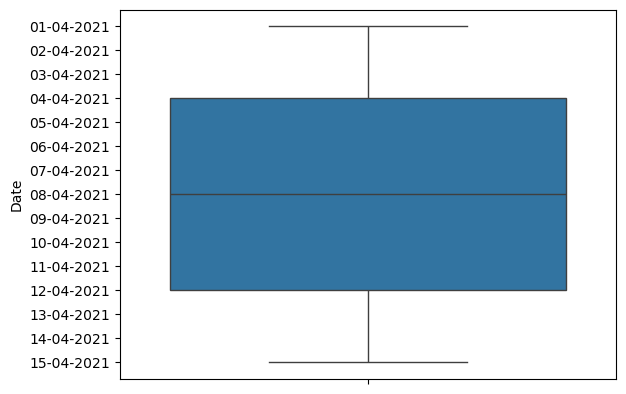

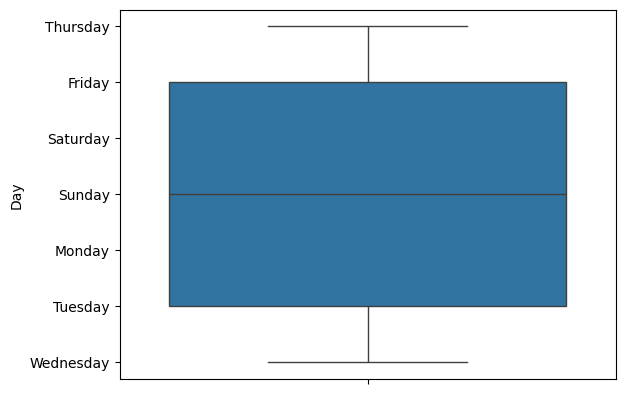

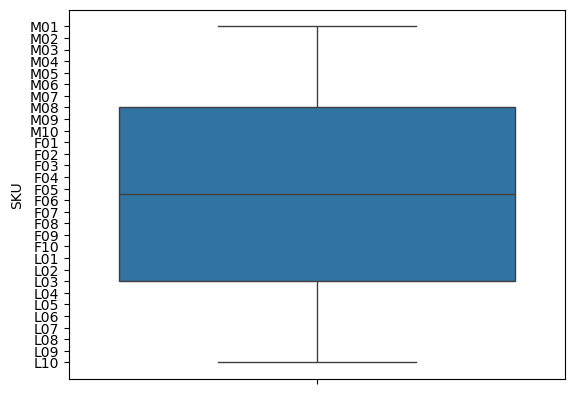

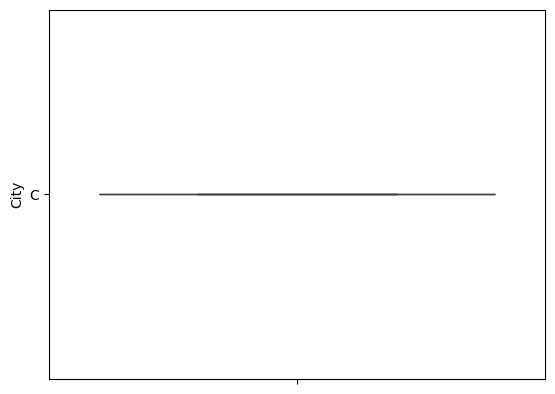

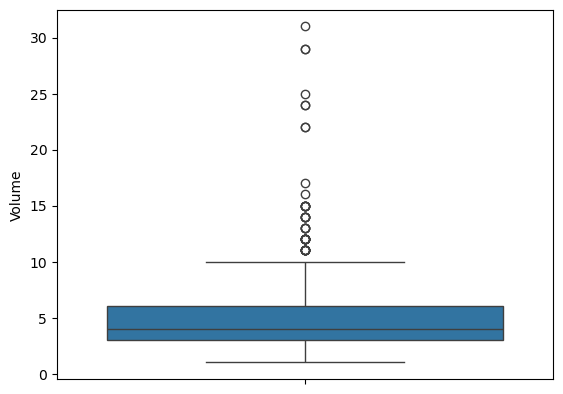

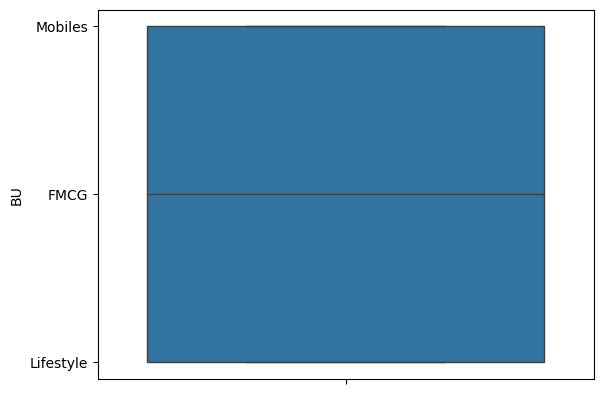

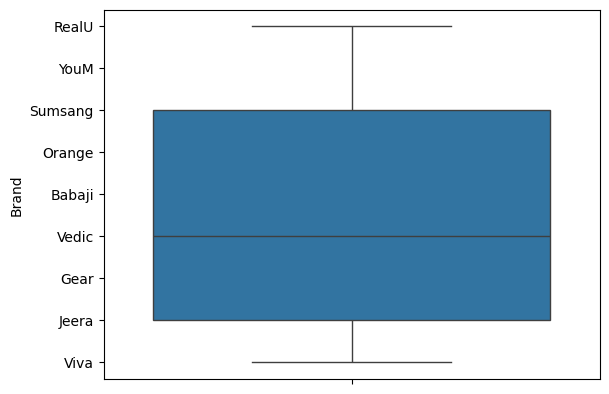

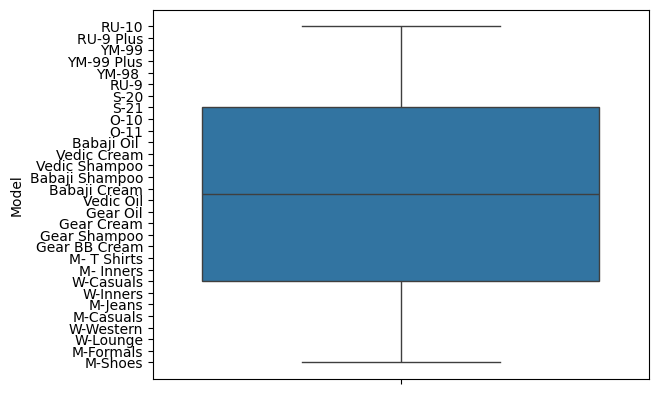

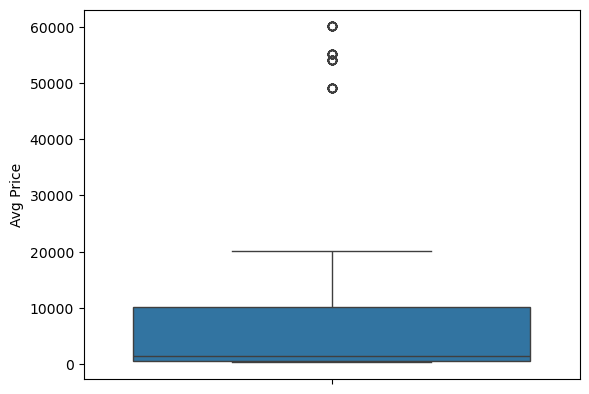

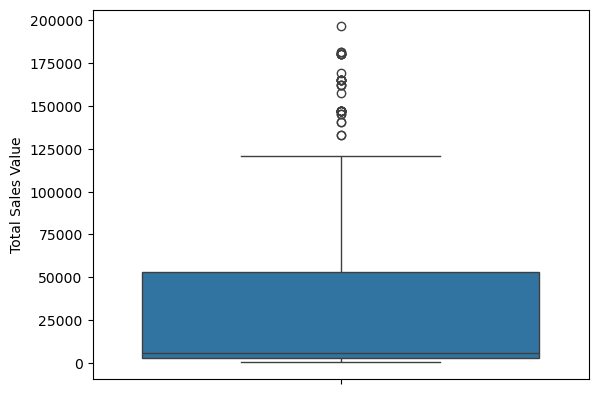

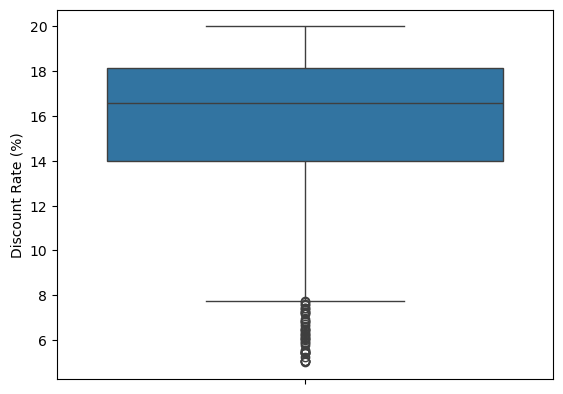

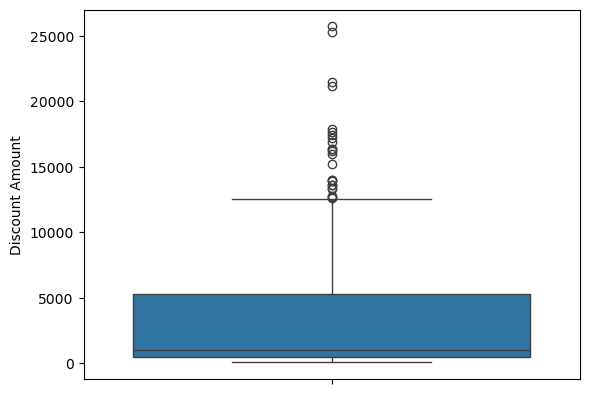

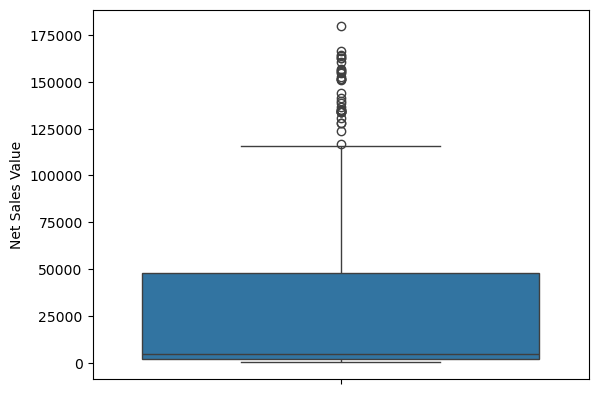

In [26]:
for col in df.columns:
    sns.boxplot(data=df,y=col)
    plt.show()

In [27]:
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
std_sca=StandardScaler()

In [30]:
df[['Volume','Avg Price','Total Sales Value','Discount Rate (%)','Discount Amount','Net Sales Value']]=std_sca.fit_transform(df[['Volume','Avg Price','Total Sales Value','Discount Rate (%)','Discount Amount','Net Sales Value']])

In [31]:
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,2.350029,Mobiles,RealU,RU-10,0.091173,2.925721,-0.830289,3.952816,2.804756
1,01-04-2021,Thursday,M02,C,1.167129,Mobiles,RealU,RU-9 Plus,-0.019570,1.330995,-0.852661,1.849014,1.271026
2,01-04-2021,Thursday,M03,C,0.457388,Mobiles,YouM,YM-99,0.312659,1.562775,-1.351631,1.622995,1.545675
3,01-04-2021,Thursday,M04,C,0.220808,Mobiles,YouM,YM-99 Plus,0.534146,1.719276,-1.949723,1.113807,1.765810
4,01-04-2021,Thursday,M05,C,-0.488932,Mobiles,YouM,YM-98,-0.130313,-0.188452,0.673739,0.227852,-0.227595
